# Phase 3C/3D: Final Sample-Size Simulation

This notebook upgrades the pilot sample-size simulation to the final high-replication Phase 3C simulation and Phase 3D simulation-based sample-size justification.

The analysis preserves the final listening-study design and uses the real standardised MST stimulus features established in Notebook 3. It remains a synthetic design analysis, not an empirical result.

## 1. Imports, Runtime Configuration, and Paths

In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata as metadata
import json
import os
import sys
import time
import traceback
import warnings
from pathlib import Path

CACHE_ROOT = Path(os.environ.get("TEMP", ".")) / "nb5finalcache"
(CACHE_ROOT / "pt" / "numba").mkdir(parents=True, exist_ok=True)
(CACHE_ROOT / "nb").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("PYTENSOR_FLAGS", f"cxx=,base_compiledir={(CACHE_ROOT / 'pt').as_posix()}")
os.environ.setdefault("NUMBA_CACHE_DIR", str(CACHE_ROOT / "nb"))

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "notebooks").exists():
    for parent in Path.cwd().parents:
        if (parent / "notebooks").exists() and (parent / "outputs").exists():
            REPO_ROOT = parent
            break

FEATURE_PATH = REPO_ROOT / "outputs" / "statistical_baseline" / "mst_feature_exploration" / "stimulus_feature_table.csv"
OUTPUT_ROOT = REPO_ROOT / "outputs" / "statistical_baseline"
OUTPUT_DIR = OUTPUT_ROOT / "sample_size_simulation"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RUN_TAG = "phase3c_final_highrep_v1"
BASE_SEED = 5500
CANDIDATE_PARTICIPANT_COUNTS = [20, 30, 40, 50, 60, 80]
REQUESTED_REPLICATIONS = 20
FALLBACK_REPLICATIONS = 10
N_REPLICATIONS = REQUESTED_REPLICATIONS
SAMPLING_CONFIG = {
    "draws": 400,
    "tune": 400,
    "chains": 2,
    "cores": 1,
    "target_accept": 0.95,
    "inference_method": "nutpie",
}
CONFIRMATION_SAMPLING_CONFIG = {
    "draws": 1000,
    "tune": 1000,
    "chains": 4,
    "cores": 1,
    "target_accept": 0.95,
    "inference_method": "nutpie",
}
OPERATIONAL_CRITERIA = {"max_divergences": 0, "max_rhat": 1.05, "min_ess": 50}
STRICT_CRITERIA = {"max_divergences": 0, "max_rhat": 1.01, "min_ess": 100}

CHECKPOINT_PATH = OUTPUT_DIR / "simulation_run_results_checkpoint_final.csv"
CONFIG_PATH = OUTPUT_DIR / "simulation_config_final.json"

def package_version(package_name: str) -> str:
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return "not installed"

version_report = pd.DataFrame(
    [
        {"component": "Python", "version": sys.version.split()[0]},
        {"component": "Bambi", "version": bmb.__version__},
        {"component": "PyMC", "version": pm.__version__},
        {"component": "ArviZ", "version": az.__version__},
        {"component": "NumPy", "version": np.__version__},
        {"component": "pandas", "version": pd.__version__},
        {"component": "matplotlib", "version": package_version("matplotlib")},
        {"component": "nutpie", "version": package_version("nutpie")},
    ]
)
display(version_report)
display(pd.DataFrame([SAMPLING_CONFIG]))
display(pd.DataFrame([CONFIRMATION_SAMPLING_CONFIG]))

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


,component,version
0,Python,3.13.9
1,Bambi,0.17.2
2,PyMC,5.28.5
3,ArviZ,0.23.4
4,NumPy,2.3.5
5,pandas,2.3.3
6,matplotlib,3.10.6
7,nutpie,0.16.11


,draws,tune,chains,cores,target_accept,inference_method
0,400,400,2,1,0.95,nutpie


,draws,tune,chains,cores,target_accept,inference_method
0,1000,1000,4,1,0.95,nutpie


## 2. Study Design and Real Stimulus Features

In [2]:
EPISODE_LEVELS = ["Relaxation", "Distraction", "Enjoyment", "Focus", "Motivation"]
MIX_LEVELS = ["Mix_1", "Mix_2", "Mix_3"]
GROUP_SONGS = {"Group_1": ["Song_1", "Song_2"], "Group_2": ["Song_3", "Song_4"]}
SONG_LEVELS = [song for songs in GROUP_SONGS.values() for song in songs]
Z_COLS = ["z_RMS", "z_CF", "z_SW", "z_SI"]
SCALAR_COLS = ["RMS", "CF", "SW", "SI"]
MODEL_FORMULA = "rating ~ episode + z_RMS + z_CF + z_SW + z_SI + episode:z_SW + episode:z_SI + (1 | participant_id)"

feature_source = pd.read_csv(FEATURE_PATH).sort_values(["song_id", "mix_id"]).reset_index(drop=True)
feature_df = feature_source.copy()
for raw, z_col in zip(SCALAR_COLS, Z_COLS):
    feature_df[z_col] = (feature_df[raw] - feature_df[raw].mean()) / feature_df[raw].std(ddof=0)
feature_df = feature_df[["stimulus_id", "song_id", "mix_id", *Z_COLS]].sort_values(["song_id", "mix_id"]).reset_index(drop=True)

feature_checks = pd.DataFrame(
    [
        {"check": "twelve_unique_stimuli", "passed": feature_df["stimulus_id"].nunique() == 12, "observed": feature_df["stimulus_id"].nunique(), "expected": 12},
        {"check": "four_songs", "passed": feature_df["song_id"].nunique() == 4, "observed": feature_df["song_id"].nunique(), "expected": 4},
        {"check": "three_stimuli_per_song", "passed": feature_df.groupby("song_id")["stimulus_id"].nunique().eq(3).all(), "observed": feature_df.groupby("song_id")["stimulus_id"].nunique().to_dict(), "expected": 3},
        {"check": "complete_z_features", "passed": feature_df[Z_COLS].notna().all().all(), "observed": feature_df[Z_COLS].isna().sum().to_dict(), "expected": "no missing"},
        {"check": "z_means_zero", "passed": np.allclose(feature_df[Z_COLS].mean(), 0, atol=1e-12), "observed": feature_df[Z_COLS].mean().round(12).to_dict(), "expected": 0},
        {"check": "z_population_sds_one", "passed": np.allclose(feature_df[Z_COLS].std(ddof=0), 1, atol=1e-12), "observed": feature_df[Z_COLS].std(ddof=0).round(12).to_dict(), "expected": 1},
    ]
)
display(feature_df.round(4))
display(feature_checks)
assert feature_checks["passed"].all()

,stimulus_id,song_id,mix_id,z_RMS,z_CF,z_SW,z_SI
0,Song_1_Mix_1,Song_1,Mix_1,1.4434,0.7856,-0.5414,-0.4988
1,Song_1_Mix_2,Song_1,Mix_2,0.3730,-0.1749,-1.3028,-0.4289
2,Song_1_Mix_3,Song_1,Mix_3,0.9363,-1.9709,0.0397,-0.6593
3,Song_2_Mix_1,Song_2,Mix_1,-0.7398,-0.8730,-0.8024,-0.1974
4,Song_2_Mix_2,Song_2,Mix_2,-1.8548,0.2300,0.2622,0.3913
5,Song_2_Mix_3,Song_2,Mix_3,-1.4264,-1.6172,1.8055,0.2313
6,Song_3_Mix_1,Song_3,Mix_1,-0.2704,-0.1324,-0.3263,-0.4603
7,Song_3_Mix_2,Song_3,Mix_2,-0.7122,0.5809,1.4183,3.1438
8,Song_3_Mix_3,Song_3,Mix_3,-0.1332,0.0836,-1.5239,-0.3498
9,Song_4_Mix_1,Song_4,Mix_1,0.4001,0.9244,1.0593,-0.0228


,check,passed,observed,expected
0,twelve_unique_stimuli,True,12,12
1,four_songs,True,4,4
2,three_stimuli_per_song,True,"{'Song_1': 3, 'Song_2': 3, 'Song_3': 3, 'Song_...",3
3,complete_z_features,True,"{'z_RMS': 0, 'z_CF': 0, 'z_SW': 0, 'z_SI': 0}",no missing
4,z_means_zero,True,"{'z_RMS': -0.0, 'z_CF': -0.0, 'z_SW': 0.0, 'z_...",0
5,z_population_sds_one,True,"{'z_RMS': 1.0, 'z_CF': 1.0, 'z_SW': 1.0, 'z_SI...",1


## 3. Final Simulation Scenarios

In [3]:
MODERATE_EPISODE_EFFECTS = {"Relaxation": 0.0, "Distraction": -2.5, "Enjoyment": 3.0, "Focus": 1.5, "Motivation": 2.5}
MODERATE_FEATURE_EFFECTS = {"z_RMS": 2.5, "z_CF": -1.8, "z_SW": 2.2, "z_SI": -1.2}
MODERATE_INTERACTIONS = {("Focus", "z_SW"): 2.0, ("Motivation", "z_SW"): 2.5, ("Distraction", "z_SI"): 1.8}

def scaled_dict(values: dict, scale: float) -> dict:
    return {key: value * scale for key, value in values.items()}

SCENARIOS = {
    "moderate_effects": {
        "display": "Moderate effects",
        "description": "Feature-driven scenario broadly matching Notebook 4.",
        "grand_mean": 63.0,
        "episode_effects": MODERATE_EPISODE_EFFECTS,
        "feature_effects": MODERATE_FEATURE_EFFECTS,
        "interactions": MODERATE_INTERACTIONS,
        "participant_sd": 7.0,
        "residual_sd": 8.5,
    },
    "smaller_effects_harder_study": {
        "display": "Smaller effects / harder study",
        "description": "Feature and interaction coefficients scaled to 60% of the moderate scenario.",
        "grand_mean": 63.0,
        "episode_effects": MODERATE_EPISODE_EFFECTS,
        "feature_effects": scaled_dict(MODERATE_FEATURE_EFFECTS, 0.6),
        "interactions": scaled_dict(MODERATE_INTERACTIONS, 0.6),
        "participant_sd": 7.0,
        "residual_sd": 8.5,
    },
    "higher_noise_moderate_effects": {
        "display": "Higher-noise moderate effects",
        "description": "Moderate coefficients retained, participant and residual variability increased.",
        "grand_mean": 63.0,
        "episode_effects": MODERATE_EPISODE_EFFECTS,
        "feature_effects": MODERATE_FEATURE_EFFECTS,
        "interactions": MODERATE_INTERACTIONS,
        "participant_sd": 10.0,
        "residual_sd": 12.0,
    },
}

scenario_rows = []
for scenario_name, params in SCENARIOS.items():
    scenario_rows.extend(
        [
            {"scenario": scenario_name, "display": params["display"], "parameter": "description", "level": "", "value": params["description"]},
            {"scenario": scenario_name, "display": params["display"], "parameter": "grand_mean", "level": "", "value": params["grand_mean"]},
            {"scenario": scenario_name, "display": params["display"], "parameter": "participant_sd", "level": "", "value": params["participant_sd"]},
            {"scenario": scenario_name, "display": params["display"], "parameter": "residual_sd", "level": "", "value": params["residual_sd"]},
        ]
    )
    for episode, value in params["episode_effects"].items():
        scenario_rows.append({"scenario": scenario_name, "display": params["display"], "parameter": "episode_effect", "level": episode, "value": value})
    for feature, value in params["feature_effects"].items():
        scenario_rows.append({"scenario": scenario_name, "display": params["display"], "parameter": "feature_effect", "level": feature, "value": value})
    for (episode, feature), value in params["interactions"].items():
        scenario_rows.append({"scenario": scenario_name, "display": params["display"], "parameter": "episode_feature_interaction", "level": f"{episode}:{feature}", "value": value})

scenarios_df = pd.DataFrame(scenario_rows)
display(scenarios_df)

,scenario,display,parameter,level,value
0,moderate_effects,Moderate effects,description,,Feature-driven scenario broadly matching Noteb...
1,moderate_effects,Moderate effects,grand_mean,,63.0
2,moderate_effects,Moderate effects,participant_sd,,7.0
3,moderate_effects,Moderate effects,residual_sd,,8.5
4,moderate_effects,Moderate effects,episode_effect,Relaxation,0.0
5,moderate_effects,Moderate effects,episode_effect,Distraction,-2.5
6,moderate_effects,Moderate effects,episode_effect,Enjoyment,3.0
7,moderate_effects,Moderate effects,episode_effect,Focus,1.5
8,moderate_effects,Moderate effects,episode_effect,Motivation,2.5
9,moderate_effects,Moderate effects,feature_effect,z_RMS,2.5


## 4. Adequacy and Diagnostic Framework

In [4]:
ADEQUACY_CRITERIA = {
    "operational_success_rate_min": 0.90,
    "cell_mean_rmse_max": 1.75,
    "cell_mean_coverage_range": [0.80, 0.98],
    "winner_accuracy_min": 0.85,
    "mean_true_winner_probability_min": 0.80,
    "average_cell_hdi_width_max": 6.50,
}
criteria_table = pd.DataFrame(
    [
        {"criterion": "Operational simulation success", "rule": "zero divergences, max R-hat <= 1.05, min ESS >= 50"},
        {"criterion": "Strong convergence", "rule": "zero divergences, max R-hat <= 1.01, min ESS >= 100"},
        {"criterion": "Adequacy: operational success", "rule": f">= {ADEQUACY_CRITERIA['operational_success_rate_min']:.2f}"},
        {"criterion": "Adequacy: cell-mean RMSE", "rule": f"<= {ADEQUACY_CRITERIA['cell_mean_rmse_max']:.2f} rating points"},
        {"criterion": "Adequacy: cell-mean HDI coverage", "rule": f"between {ADEQUACY_CRITERIA['cell_mean_coverage_range'][0]:.2f} and {ADEQUACY_CRITERIA['cell_mean_coverage_range'][1]:.2f}"},
        {"criterion": "Adequacy: winner accuracy", "rule": f">= {ADEQUACY_CRITERIA['winner_accuracy_min']:.2f}"},
        {"criterion": "Adequacy: posterior probability for true winner", "rule": f">= {ADEQUACY_CRITERIA['mean_true_winner_probability_min']:.2f}"},
        {"criterion": "Adequacy: mean cell interval width", "rule": f"<= {ADEQUACY_CRITERIA['average_cell_hdi_width_max']:.2f} rating points"},
    ]
)
display(criteria_table)

,criterion,rule
0,Operational simulation success,"zero divergences, max R-hat <= 1.05, min ESS >..."
1,Strong convergence,"zero divergences, max R-hat <= 1.01, min ESS >..."
2,Adequacy: operational success,>= 0.90
3,Adequacy: cell-mean RMSE,<= 1.75 rating points
4,Adequacy: cell-mean HDI coverage,between 0.80 and 0.98
5,Adequacy: winner accuracy,>= 0.85
6,Adequacy: posterior probability for true winner,>= 0.80
7,Adequacy: mean cell interval width,<= 6.50 rating points


## 5. Restart-Safe Simulation Functions

In [5]:
def json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [json_safe(v) for v in obj]
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    return obj

scenario_config_for_hash = {
    name: {
        "grand_mean": p["grand_mean"],
        "episode_effects": p["episode_effects"],
        "feature_effects": p["feature_effects"],
        "interactions": {f"{k[0]}:{k[1]}": v for k, v in p["interactions"].items()},
        "participant_sd": p["participant_sd"],
        "residual_sd": p["residual_sd"],
    }
    for name, p in SCENARIOS.items()
}
SIMULATION_CONFIG = {
    "run_tag": RUN_TAG,
    "candidate_participant_counts": CANDIDATE_PARTICIPANT_COUNTS,
    "n_replications": N_REPLICATIONS,
    "sampling_config": SAMPLING_CONFIG,
    "model_formula": MODEL_FORMULA,
    "scenarios": scenario_config_for_hash,
    "operational_criteria": OPERATIONAL_CRITERIA,
    "strict_criteria": STRICT_CRITERIA,
}
CONFIG_HASH = hashlib.sha256(json.dumps(json_safe(SIMULATION_CONFIG), sort_keys=True).encode("utf-8")).hexdigest()[:16]
SIMULATION_CONFIG["config_hash"] = CONFIG_HASH
CONFIG_PATH.write_text(json.dumps(json_safe(SIMULATION_CONFIG), indent=2), encoding="utf-8")
print(f"Final simulation config hash: {CONFIG_HASH}")

def participant_group_for_index(index: int, n_participants: int) -> str:
    split = int(np.ceil(n_participants / 2))
    return "Group_1" if index < split else "Group_2"

def expected_rating_from_params(row: pd.Series, params: dict) -> float:
    value = params["grand_mean"] + params["episode_effects"][str(row["episode"])]
    for feature, beta in params["feature_effects"].items():
        value += beta * float(row[feature])
    for (episode, feature), beta in params["interactions"].items():
        if str(row["episode"]) == episode:
            value += beta * float(row[feature])
    return value

def generate_dataset(n_participants: int, params: dict, seed: int) -> tuple[pd.DataFrame, int]:
    local_rng = np.random.default_rng(seed)
    feature_lookup = feature_df.set_index(["song_id", "mix_id"])
    participant_ids = [f"P{i:03d}" for i in range(1, n_participants + 1)]
    participant_groups = {pid: participant_group_for_index(i, n_participants) for i, pid in enumerate(participant_ids)}
    participant_intercepts = {pid: local_rng.normal(0, params["participant_sd"]) for pid in participant_ids}
    rows, raw_ratings = [], []
    for participant_id in participant_ids:
        group = participant_groups[participant_id]
        for song_id in GROUP_SONGS[group]:
            for episode in EPISODE_LEVELS:
                for presentation_order, mix_id in enumerate(local_rng.permutation(MIX_LEVELS), start=1):
                    frow = feature_lookup.loc[(song_id, mix_id)]
                    base = {
                        "participant_id": participant_id,
                        "group": group,
                        "song_id": song_id,
                        "mix_id": mix_id,
                        "stimulus_id": frow["stimulus_id"],
                        "episode": episode,
                        "presentation_order": presentation_order,
                        **{col: float(frow[col]) for col in Z_COLS},
                    }
                    population_mean = expected_rating_from_params(pd.Series(base), params)
                    expected_rating = population_mean + participant_intercepts[participant_id]
                    raw_rating = local_rng.normal(expected_rating, params["residual_sd"])
                    raw_ratings.append(raw_rating)
                    rows.append({**base, "expected_rating": expected_rating, "rating": float(np.clip(raw_rating, 0, 100))})
    clipped = int(((np.asarray(raw_ratings) < 0) | (np.asarray(raw_ratings) > 100)).sum())
    return pd.DataFrame(rows), clipped

def category_model_df(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    out = df.copy()
    levels = {
        "participant_id": sorted(out["participant_id"].unique()),
        "group": ["Group_1", "Group_2"],
        "song_id": SONG_LEVELS,
        "mix_id": MIX_LEVELS,
        "stimulus_id": [f"{song}_{mix}" for song in SONG_LEVELS for mix in MIX_LEVELS],
        "episode": EPISODE_LEVELS,
    }
    for col, cats in levels.items():
        out[col] = pd.Categorical(out[col], categories=cats, ordered=False)
    return out, levels

def prediction_grid_for_levels(levels: dict) -> pd.DataFrame:
    grid = pd.DataFrame(
        [(episode, song_id, mix_id) for episode in EPISODE_LEVELS for song_id in SONG_LEVELS for mix_id in MIX_LEVELS],
        columns=["episode", "song_id", "mix_id"],
    ).merge(feature_df[["song_id", "mix_id", "stimulus_id", *Z_COLS]], on=["song_id", "mix_id"], how="left")
    grid["participant_id"] = levels["participant_id"][0]
    grid["group"] = np.where(grid["song_id"].isin(GROUP_SONGS["Group_1"]), "Group_1", "Group_2")
    for col, cats in levels.items():
        grid[col] = pd.Categorical(grid[col], categories=cats, ordered=False)
    return grid

PRIORS = {
    "Intercept": bmb.Prior("Normal", mu=65, sigma=20),
    "episode": bmb.Prior("Normal", mu=0, sigma=8),
    "z_RMS": bmb.Prior("Normal", mu=0, sigma=8),
    "z_CF": bmb.Prior("Normal", mu=0, sigma=8),
    "z_SW": bmb.Prior("Normal", mu=0, sigma=8),
    "z_SI": bmb.Prior("Normal", mu=0, sigma=8),
    "episode:z_SW": bmb.Prior("Normal", mu=0, sigma=5),
    "episode:z_SI": bmb.Prior("Normal", mu=0, sigma=5),
    "1|participant_id": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=10)),
    "sigma": bmb.Prior("HalfNormal", sigma=15),
}

def diagnostic_metrics(idata) -> dict:
    summary = az.summary(idata, round_to=None)
    sample_stats = idata.sample_stats
    divergences = int(sample_stats["diverging"].sum().item()) if "diverging" in sample_stats else 0
    max_rhat = float(summary["r_hat"].max(skipna=True))
    min_ess = float(min(summary["ess_bulk"].min(skipna=True), summary["ess_tail"].min(skipna=True)))
    operational = divergences <= OPERATIONAL_CRITERIA["max_divergences"] and max_rhat <= OPERATIONAL_CRITERIA["max_rhat"] and min_ess >= OPERATIONAL_CRITERIA["min_ess"]
    strict = divergences <= STRICT_CRITERIA["max_divergences"] and max_rhat <= STRICT_CRITERIA["max_rhat"] and min_ess >= STRICT_CRITERIA["min_ess"]
    return {"divergences": divergences, "max_rhat": max_rhat, "min_ess": min_ess, "operational_success": bool(operational), "strict_convergence": bool(strict)}

def extracted_posterior(idata):
    return az.extract(idata, group="posterior", combined=True)

def scalar_draws(extracted, var_name: str) -> np.ndarray:
    return np.asarray(extracted[var_name]).reshape(-1)

def indexed_draws(extracted, var_name: str, level: str) -> np.ndarray:
    da = extracted[var_name]
    non_sample_dims = [dim for dim in da.dims if dim != "sample"]
    dim = non_sample_dims[0]
    labels = [str(value) for value in da[dim].values]
    if level not in labels:
        return np.zeros(extracted.sizes["sample"])
    return np.asarray(da.isel({dim: labels.index(level)})).reshape(-1)

def summarise_coef_draws(draws: np.ndarray, truth: float, group: str) -> dict:
    hdi = az.hdi(draws, hdi_prob=0.94)
    estimate = float(draws.mean())
    return {
        "coefficient_group": group,
        "true": truth,
        "estimate": estimate,
        "bias": estimate - truth,
        "absolute_error": abs(estimate - truth),
        "squared_error": (estimate - truth) ** 2,
        "covered": bool(hdi[0] <= truth <= hdi[1]),
        "sign_recovered": bool(np.sign(estimate) == np.sign(truth)) if truth != 0 else np.nan,
        "hdi_width": float(hdi[1] - hdi[0]),
    }

def coefficient_recovery_metrics(idata, params: dict) -> dict:
    ext = extracted_posterior(idata)
    rows = [
        summarise_coef_draws(scalar_draws(ext, "z_RMS"), params["feature_effects"]["z_RMS"], "main_effect"),
        summarise_coef_draws(scalar_draws(ext, "z_CF"), params["feature_effects"]["z_CF"], "main_effect"),
        summarise_coef_draws(scalar_draws(ext, "z_SW"), params["feature_effects"]["z_SW"], "main_effect"),
        summarise_coef_draws(scalar_draws(ext, "z_SI"), params["feature_effects"]["z_SI"], "main_effect"),
    ]
    for episode in EPISODE_LEVELS:
        sw_truth = params["feature_effects"]["z_SW"] + params["interactions"].get((episode, "z_SW"), 0.0)
        si_truth = params["feature_effects"]["z_SI"] + params["interactions"].get((episode, "z_SI"), 0.0)
        rows.append(summarise_coef_draws(scalar_draws(ext, "z_SW") + indexed_draws(ext, "episode:z_SW", episode), sw_truth, "episode_specific_interaction_slope"))
        rows.append(summarise_coef_draws(scalar_draws(ext, "z_SI") + indexed_draws(ext, "episode:z_SI", episode), si_truth, "episode_specific_interaction_slope"))
    coef = pd.DataFrame(rows)
    metrics = {}
    for group_name, group_df in coef.groupby("coefficient_group"):
        nonzero = group_df["sign_recovered"].notna()
        metrics.update(
            {
                f"{group_name}_bias_mean": float(group_df["bias"].mean()),
                f"{group_name}_mae": float(group_df["absolute_error"].mean()),
                f"{group_name}_rmse": float(np.sqrt(group_df["squared_error"].mean())),
                f"{group_name}_coverage": float(group_df["covered"].mean()),
                f"{group_name}_sign_recovery": float(group_df.loc[nonzero, "sign_recovered"].mean()),
                f"{group_name}_hdi_width_mean": float(group_df["hdi_width"].mean()),
            }
        )
    metrics["coefficient_rmse"] = float(np.sqrt(coef["squared_error"].mean()))
    metrics["coefficient_coverage"] = float(coef["covered"].mean())
    metrics["coefficient_sign_recovery"] = float(coef.loc[coef["sign_recovered"].notna(), "sign_recovered"].mean())
    metrics["coefficient_hdi_width_mean"] = float(coef["hdi_width"].mean())
    return metrics

def prediction_metrics(model, idata, levels: dict, params: dict) -> dict:
    grid = prediction_grid_for_levels(levels)
    pred_idata = model.predict(idata, kind="response_params", data=grid, inplace=False, include_group_specific=False)
    mu = pred_idata.posterior["mu"].values
    mu_draws = mu.reshape(-1, mu.shape[-1])
    true_means = grid.apply(lambda row: expected_rating_from_params(row, params), axis=1).to_numpy()
    post_mean = mu_draws.mean(axis=0)
    hdi = az.hdi(mu_draws, hdi_prob=0.94)
    widths = hdi[:, 1] - hdi[:, 0]
    errors = post_mean - true_means
    covered = (hdi[:, 0] <= true_means) & (true_means <= hdi[:, 1])

    winner_rows = []
    for episode in EPISODE_LEVELS:
        for song_id in SONG_LEVELS:
            mask = (grid["episode"].astype(str).eq(episode)) & (grid["song_id"].astype(str).eq(song_id))
            idx = np.flatnonzero(mask.to_numpy())
            song_true = true_means[idx]
            true_max = song_true.max()
            true_winner_mask = np.isclose(song_true, true_max, rtol=0.0, atol=1e-12)
            song_draws = mu_draws[:, idx]
            draw_max = song_draws.max(axis=1, keepdims=True)
            draw_winner_mask = np.isclose(song_draws, draw_max, rtol=0.0, atol=1e-12)
            draw_weights = draw_winner_mask / draw_winner_mask.sum(axis=1, keepdims=True)
            win_prob = draw_weights.mean(axis=0)
            predicted_winner = int(np.argmax(win_prob))
            true_winner_credit = float(win_prob[true_winner_mask].sum())
            winner_rows.append(
                {
                    "winner_accuracy": bool(true_winner_mask[predicted_winner]),
                    "true_winner_probability": true_winner_credit,
                    "true_winner_prob_gt_0_50": bool(true_winner_credit > 0.50),
                    "true_tie": bool(true_winner_mask.sum() > 1),
                }
            )
    winners = pd.DataFrame(winner_rows)
    return {
        "cell_mean_rmse": float(np.sqrt(np.mean(errors ** 2))),
        "cell_mean_mae": float(np.mean(np.abs(errors))),
        "cell_mean_coverage": float(covered.mean()),
        "average_cell_hdi_width": float(widths.mean()),
        "winner_accuracy": float(winners["winner_accuracy"].mean()),
        "mean_probability_true_winner": float(winners["true_winner_probability"].mean()),
        "true_winner_probability_gt_0_50_rate": float(winners["true_winner_prob_gt_0_50"].mean()),
        "true_winner_tie_count": int(winners["true_tie"].sum()),
    }

def fit_and_evaluate(scenario_name: str, params: dict, n_participants: int, replication: int, seed: int, sampling_config: dict) -> dict:
    started = time.time()
    result = {"run_tag": RUN_TAG, "config_hash": CONFIG_HASH, "scenario": scenario_name, "participant_count": n_participants, "replication": replication, "seed": seed}
    warning_records = []
    try:
        df, clipped = generate_dataset(n_participants, params, seed)
        model_df, levels = category_model_df(df)
        model = bmb.Model(MODEL_FORMULA, model_df, family="gaussian", priors=PRIORS)
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            idata = model.fit(progressbar=False, random_seed=seed, **sampling_config)
        warning_records = [f"{w.category.__name__}: {str(w.message)[:160]}" for w in caught]
        result.update(diagnostic_metrics(idata))
        result.update(coefficient_recovery_metrics(idata, params))
        result.update(prediction_metrics(model, idata, levels, params))
        result.update({"rows": len(df), "clipped_ratings": clipped, "failed": False, "error_type": "", "error_summary": ""})
    except Exception as exc:
        result.update(
            {
                "failed": True,
                "operational_success": False,
                "strict_convergence": False,
                "error_type": type(exc).__name__,
                "error_summary": "".join(traceback.format_exception_only(type(exc), exc)).strip()[:500],
            }
        )
    result["warning_count"] = len(warning_records)
    result["warning_summary"] = " | ".join(warning_records[:3])
    result["elapsed_seconds"] = time.time() - started
    return result

def replication_seed(scenario_name: str, participant_count: int, replication: int, offset: int = 0) -> int:
    scenario_index = list(SCENARIOS).index(scenario_name) + 1
    return BASE_SEED + offset + scenario_index * 100000 + participant_count * 1000 + replication

def load_checkpoint() -> pd.DataFrame:
    if not CHECKPOINT_PATH.exists():
        return pd.DataFrame()
    df = pd.read_csv(CHECKPOINT_PATH)
    required = {"run_tag", "config_hash", "scenario", "participant_count", "replication"}
    if not required.issubset(df.columns):
        return pd.DataFrame()
    return df[df["run_tag"].eq(RUN_TAG) & df["config_hash"].eq(CONFIG_HASH)].copy()

def write_checkpoint(df: pd.DataFrame) -> None:
    df.sort_values(["scenario", "participant_count", "replication"]).to_csv(CHECKPOINT_PATH, index=False)

Final simulation config hash: 350ccb9c668fdd57


## 6. Execute or Resume Final High-Replication Simulation

In [6]:
planned_keys = [
    (scenario_name, participant_count, replication)
    for scenario_name in SCENARIOS
    for participant_count in CANDIDATE_PARTICIPANT_COUNTS
    for replication in range(1, N_REPLICATIONS + 1)
]
attempted_fits = len(planned_keys)
print(f"Requested final replication target: {REQUESTED_REPLICATIONS} per condition")
print(f"Planned final model fits: {attempted_fits}")

checkpoint_df = load_checkpoint()
completed_keys = set()
if len(checkpoint_df):
    completed_keys = set(zip(checkpoint_df["scenario"], checkpoint_df["participant_count"].astype(int), checkpoint_df["replication"].astype(int)))
    print(f"Resuming from {len(completed_keys)} compatible checkpointed fits.")

results = checkpoint_df.to_dict(orient="records") if len(checkpoint_df) else []
for scenario_name, participant_count, replication in planned_keys:
    key = (scenario_name, participant_count, replication)
    if key in completed_keys:
        continue
    seed = replication_seed(scenario_name, participant_count, replication)
    print(f"{scenario_name} | n={participant_count} | replication {replication}/{N_REPLICATIONS}")
    result = fit_and_evaluate(scenario_name, SCENARIOS[scenario_name], participant_count, replication, seed, SAMPLING_CONFIG)
    results.append(result)
    write_checkpoint(pd.DataFrame(results))

run_results_df = pd.DataFrame(results)
run_results_df = run_results_df[run_results_df["config_hash"].eq(CONFIG_HASH)].copy()
display(run_results_df[["scenario", "participant_count", "replication", "failed", "operational_success", "strict_convergence", "divergences", "max_rhat", "min_ess", "cell_mean_rmse", "winner_accuracy", "average_cell_hdi_width", "warning_count", "elapsed_seconds"]].round(3).tail(20))

Requested final replication target: 20 per condition
Planned final model fits: 360
Resuming from 360 compatible checkpointed fits.


,scenario,participant_count,replication,failed,operational_success,strict_convergence,divergences,max_rhat,min_ess,cell_mean_rmse,winner_accuracy,average_cell_hdi_width,warning_count,elapsed_seconds
340,smaller_effects_harder_study,80,1,False,False,False,0,1.05,46.0,0.677,0.85,3.911,0,6.281
341,smaller_effects_harder_study,80,2,False,False,False,0,1.06,37.0,1.701,0.80,3.803,0,8.447
342,smaller_effects_harder_study,80,3,False,True,False,0,1.03,66.0,0.908,0.90,3.825,0,6.478
343,smaller_effects_harder_study,80,4,False,True,False,0,1.05,59.0,0.785,0.90,3.474,0,7.227
344,smaller_effects_harder_study,80,5,False,False,False,0,1.15,12.0,0.938,0.90,4.444,0,7.358
345,smaller_effects_harder_study,80,6,False,True,False,0,1.03,53.0,0.606,0.90,3.760,0,7.708
346,smaller_effects_harder_study,80,7,False,False,False,0,1.07,51.0,0.970,0.90,3.674,0,7.538
347,smaller_effects_harder_study,80,8,False,True,False,0,1.01,86.0,2.652,0.80,3.683,0,8.083
348,smaller_effects_harder_study,80,9,False,True,False,0,1.03,66.0,1.083,1.00,3.854,0,7.824
349,smaller_effects_harder_study,80,10,False,False,False,0,1.07,26.0,1.950,0.90,3.803,0,9.434


## 7. Final Sample-Size Summaries

In [7]:
failed_fits = run_results_df[run_results_df["failed"]].copy()
completed = run_results_df[~run_results_df["failed"]].copy()

def se(series: pd.Series) -> float:
    return float(series.std(ddof=1) / np.sqrt(series.count())) if series.count() > 1 else np.nan

sample_size_summary = (
    completed
    .groupby(["scenario", "participant_count"], as_index=False)
    .agg(
        replications_completed=("replication", "count"),
        operational_success_rate=("operational_success", "mean"),
        strict_convergence_rate=("strict_convergence", "mean"),
        divergence_rate=("divergences", lambda s: float((s > 0).mean())),
        median_max_rhat=("max_rhat", "median"),
        median_min_ess=("min_ess", "median"),
        warning_count_mean=("warning_count", "mean"),
        main_effect_rmse_mean=("main_effect_rmse", "mean"),
        main_effect_coverage_mean=("main_effect_coverage", "mean"),
        main_effect_sign_recovery_mean=("main_effect_sign_recovery", "mean"),
        interaction_slope_rmse_mean=("episode_specific_interaction_slope_rmse", "mean"),
        interaction_slope_coverage_mean=("episode_specific_interaction_slope_coverage", "mean"),
        interaction_slope_sign_recovery_mean=("episode_specific_interaction_slope_sign_recovery", "mean"),
        coefficient_rmse_mean=("coefficient_rmse", "mean"),
        coefficient_coverage_mean=("coefficient_coverage", "mean"),
        coefficient_sign_recovery_mean=("coefficient_sign_recovery", "mean"),
        coefficient_hdi_width_mean=("coefficient_hdi_width_mean", "mean"),
        cell_mean_rmse_mean=("cell_mean_rmse", "mean"),
        cell_mean_rmse_sd=("cell_mean_rmse", "std"),
        cell_mean_rmse_se=("cell_mean_rmse", se),
        cell_mean_rmse_q10=("cell_mean_rmse", lambda s: float(s.quantile(0.10))),
        cell_mean_rmse_q90=("cell_mean_rmse", lambda s: float(s.quantile(0.90))),
        cell_mean_mae_mean=("cell_mean_mae", "mean"),
        cell_mean_coverage_mean=("cell_mean_coverage", "mean"),
        cell_mean_coverage_sd=("cell_mean_coverage", "std"),
        cell_mean_coverage_se=("cell_mean_coverage", se),
        winner_accuracy_mean=("winner_accuracy", "mean"),
        winner_accuracy_sd=("winner_accuracy", "std"),
        winner_accuracy_se=("winner_accuracy", se),
        mean_probability_true_winner=("mean_probability_true_winner", "mean"),
        true_winner_probability_gt_0_50_rate=("true_winner_probability_gt_0_50_rate", "mean"),
        true_winner_tie_count_total=("true_winner_tie_count", "sum"),
        average_cell_hdi_width_mean=("average_cell_hdi_width", "mean"),
        average_cell_hdi_width_sd=("average_cell_hdi_width", "std"),
        average_cell_hdi_width_se=("average_cell_hdi_width", se),
        elapsed_seconds_total=("elapsed_seconds", "sum"),
    )
)

sample_size_summary["coverage_in_adequacy_range"] = sample_size_summary["cell_mean_coverage_mean"].between(*ADEQUACY_CRITERIA["cell_mean_coverage_range"])
sample_size_summary["passes_recovery_adequacy_rule"] = (
    sample_size_summary["cell_mean_rmse_mean"].le(ADEQUACY_CRITERIA["cell_mean_rmse_max"])
    & sample_size_summary["coverage_in_adequacy_range"]
    & sample_size_summary["winner_accuracy_mean"].ge(ADEQUACY_CRITERIA["winner_accuracy_min"])
    & sample_size_summary["mean_probability_true_winner"].ge(ADEQUACY_CRITERIA["mean_true_winner_probability_min"])
    & sample_size_summary["average_cell_hdi_width_mean"].le(ADEQUACY_CRITERIA["average_cell_hdi_width_max"])
)
sample_size_summary["passes_adequacy_rule"] = (
    sample_size_summary["operational_success_rate"].ge(ADEQUACY_CRITERIA["operational_success_rate_min"])
    & sample_size_summary["passes_recovery_adequacy_rule"]
)

dissertation_summary_table = sample_size_summary[
    [
        "scenario", "participant_count", "replications_completed", "operational_success_rate", "strict_convergence_rate",
        "cell_mean_rmse_mean", "cell_mean_rmse_se", "cell_mean_coverage_mean", "winner_accuracy_mean",
        "winner_accuracy_se", "mean_probability_true_winner", "true_winner_probability_gt_0_50_rate",
        "average_cell_hdi_width_mean", "passes_recovery_adequacy_rule", "passes_adequacy_rule",
    ]
].copy()
sample_size_40_vs_50 = dissertation_summary_table[dissertation_summary_table["participant_count"].isin([40, 50])].copy()

display(dissertation_summary_table.round(3))
display(sample_size_40_vs_50.round(3))

,scenario,participant_count,replications_completed,operational_success_rate,strict_convergence_rate,cell_mean_rmse_mean,cell_mean_rmse_se,cell_mean_coverage_mean,winner_accuracy_mean,winner_accuracy_se,mean_probability_true_winner,true_winner_probability_gt_0_50_rate,average_cell_hdi_width_mean,passes_recovery_adequacy_rule,passes_adequacy_rule
0,higher_noise_moderate_effects,20,20,0.85,0.15,2.730,0.254,0.903,0.865,0.012,0.815,0.860,10.564,False,False
1,higher_noise_moderate_effects,30,20,0.75,0.00,2.395,0.193,0.925,0.878,0.016,0.836,0.872,9.000,False,False
2,higher_noise_moderate_effects,40,20,0.65,0.00,2.181,0.172,0.911,0.880,0.014,0.849,0.878,7.671,False,False
3,higher_noise_moderate_effects,50,20,0.45,0.00,1.601,0.104,0.972,0.882,0.017,0.865,0.882,6.987,False,False
4,higher_noise_moderate_effects,60,20,0.20,0.00,1.561,0.135,0.949,0.893,0.017,0.869,0.893,6.468,True,False
5,higher_noise_moderate_effects,80,20,0.35,0.00,1.736,0.084,0.887,0.872,0.012,0.870,0.870,5.483,True,False
6,moderate_effects,20,20,0.75,0.05,1.945,0.177,0.939,0.910,0.014,0.862,0.905,7.938,False,False
7,moderate_effects,30,20,0.65,0.05,1.583,0.112,0.950,0.895,0.011,0.869,0.893,6.355,True,False
8,moderate_effects,40,20,0.55,0.00,1.545,0.133,0.918,0.918,0.012,0.891,0.918,5.604,True,False
9,moderate_effects,50,20,0.25,0.00,1.234,0.100,0.935,0.910,0.013,0.886,0.910,5.048,True,False


,scenario,participant_count,replications_completed,operational_success_rate,strict_convergence_rate,cell_mean_rmse_mean,cell_mean_rmse_se,cell_mean_coverage_mean,winner_accuracy_mean,winner_accuracy_se,mean_probability_true_winner,true_winner_probability_gt_0_50_rate,average_cell_hdi_width_mean,passes_recovery_adequacy_rule,passes_adequacy_rule
2,higher_noise_moderate_effects,40,20,0.65,0.0,2.181,0.172,0.911,0.880,0.014,0.849,0.878,7.671,False,False
3,higher_noise_moderate_effects,50,20,0.45,0.0,1.601,0.104,0.972,0.882,0.017,0.865,0.882,6.987,False,False
8,moderate_effects,40,20,0.55,0.0,1.545,0.133,0.918,0.918,0.012,0.891,0.918,5.604,True,False
9,moderate_effects,50,20,0.25,0.0,1.234,0.100,0.935,0.910,0.013,0.886,0.910,5.048,True,False
14,smaller_effects_harder_study,40,20,0.35,0.0,1.542,0.138,0.885,0.890,0.014,0.846,0.888,5.610,True,False
15,smaller_effects_harder_study,50,20,0.35,0.0,1.344,0.117,0.909,0.865,0.015,0.833,0.865,4.900,True,False


## 8. Diminishing Returns

In [8]:
diminishing_rows = []
for scenario, group in sample_size_summary.sort_values("participant_count").groupby("scenario"):
    group = group.sort_values("participant_count").reset_index(drop=True)
    for i in range(1, len(group)):
        prev = group.iloc[i - 1]
        curr = group.iloc[i]
        diminishing_rows.append(
            {
                "scenario": scenario,
                "transition": f"{int(prev.participant_count)} -> {int(curr.participant_count)}",
                "from_n": int(prev.participant_count),
                "to_n": int(curr.participant_count),
                "cell_mean_rmse_change": curr.cell_mean_rmse_mean - prev.cell_mean_rmse_mean,
                "winner_accuracy_change": curr.winner_accuracy_mean - prev.winner_accuracy_mean,
                "true_winner_probability_change": curr.mean_probability_true_winner - prev.mean_probability_true_winner,
                "uncertainty_width_change": curr.average_cell_hdi_width_mean - prev.average_cell_hdi_width_mean,
                "coverage_change": curr.cell_mean_coverage_mean - prev.cell_mean_coverage_mean,
                "operational_success_rate_change": curr.operational_success_rate - prev.operational_success_rate,
            }
        )
diminishing_returns = pd.DataFrame(diminishing_rows)
display(diminishing_returns.round(3))

,scenario,transition,from_n,to_n,cell_mean_rmse_change,winner_accuracy_change,true_winner_probability_change,uncertainty_width_change,coverage_change,operational_success_rate_change
0,higher_noise_moderate_effects,20 -> 30,20,30,-0.334,0.013,0.021,-1.565,0.022,-0.10
1,higher_noise_moderate_effects,30 -> 40,30,40,-0.214,0.003,0.013,-1.329,-0.014,-0.10
2,higher_noise_moderate_effects,40 -> 50,40,50,-0.580,0.002,0.016,-0.683,0.061,-0.20
3,higher_noise_moderate_effects,50 -> 60,50,60,-0.041,0.010,0.004,-0.519,-0.022,-0.25
4,higher_noise_moderate_effects,60 -> 80,60,80,0.175,-0.020,0.001,-0.986,-0.062,0.15
5,moderate_effects,20 -> 30,20,30,-0.361,-0.015,0.008,-1.583,0.011,-0.10
6,moderate_effects,30 -> 40,30,40,-0.038,0.023,0.021,-0.751,-0.032,-0.10
7,moderate_effects,40 -> 50,40,50,-0.311,-0.008,-0.005,-0.556,0.017,-0.30
8,moderate_effects,50 -> 60,50,60,0.185,-0.002,0.005,-0.462,-0.073,0.15
9,moderate_effects,60 -> 80,60,80,-0.477,0.025,0.016,-0.673,0.077,0.00


## 9. Dissertation-Ready Figures

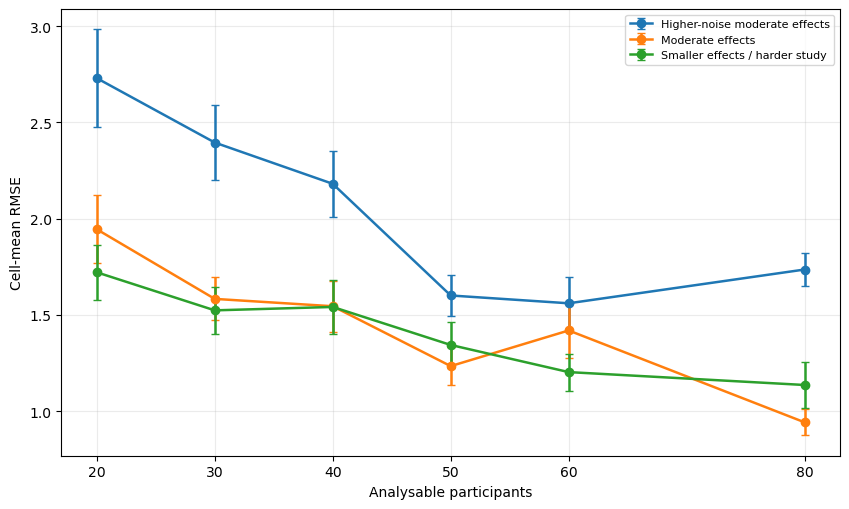

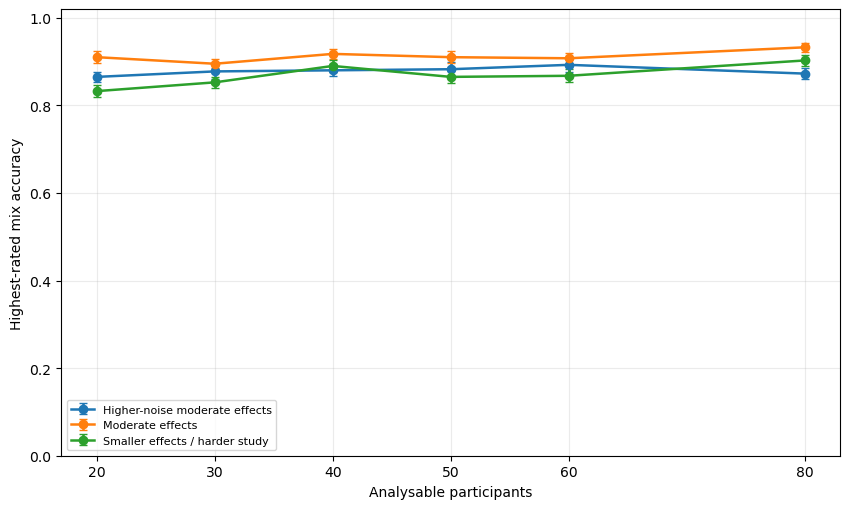

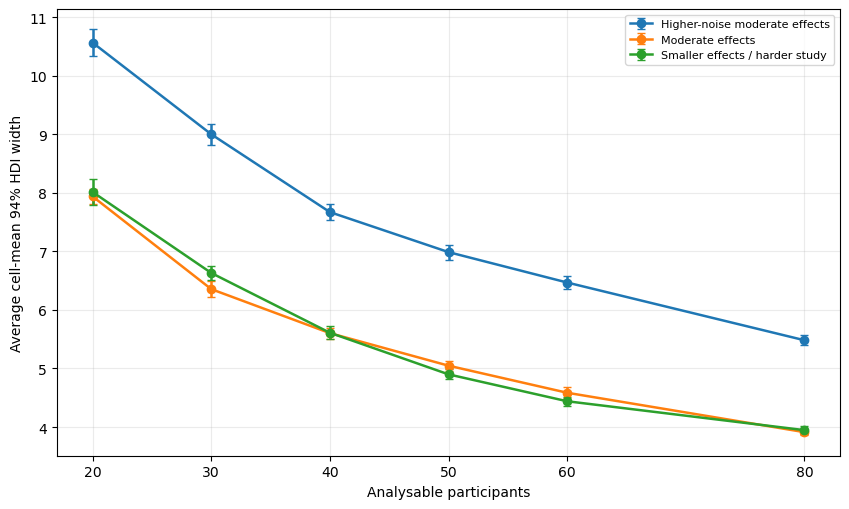

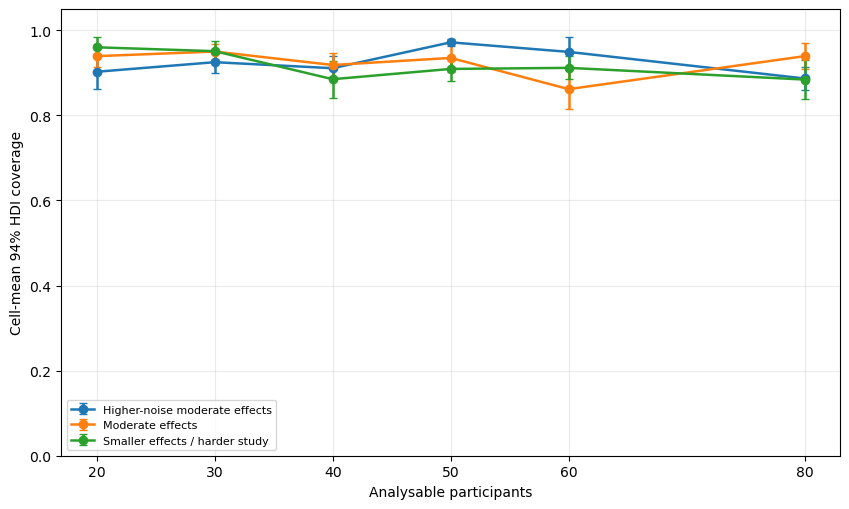

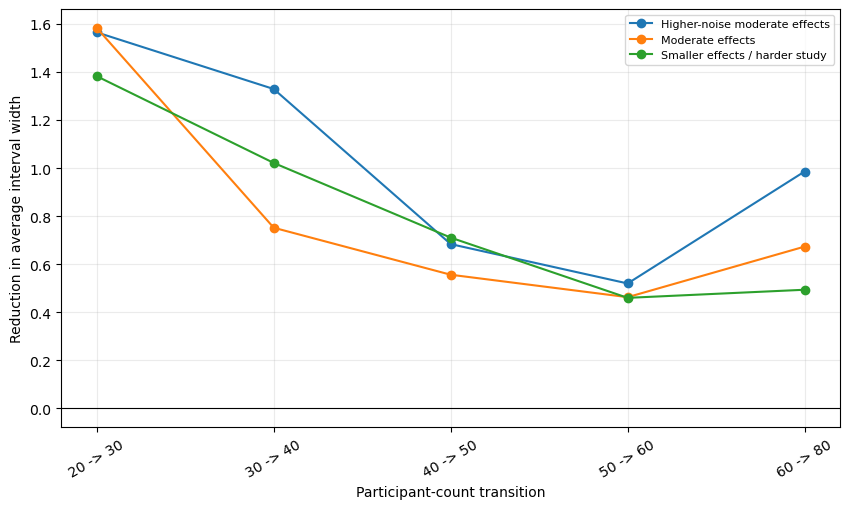

In [9]:
scenario_labels = {name: params["display"] for name, params in SCENARIOS.items()}

def line_plot(metric: str, ylabel: str, filename: str, error_col: str | None = None, ylim=None):
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    for scenario, group in sample_size_summary.groupby("scenario"):
        group = group.sort_values("participant_count")
        label = scenario_labels.get(scenario, scenario)
        yerr = group[error_col] if error_col and error_col in group else None
        ax.errorbar(group["participant_count"], group[metric], yerr=yerr, marker="o", capsize=3, linewidth=1.8, label=label)
    ax.set_xlabel("Analysable participants")
    ax.set_ylabel(ylabel)
    ax.set_xticks(CANDIDATE_PARTICIPANT_COUNTS)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=180)
    plt.show()

line_plot("cell_mean_rmse_mean", "Cell-mean RMSE", "final_participant_count_vs_cell_mean_rmse.png", "cell_mean_rmse_se")
line_plot("winner_accuracy_mean", "Highest-rated mix accuracy", "final_participant_count_vs_winner_accuracy.png", "winner_accuracy_se", (0.0, 1.02))
line_plot("average_cell_hdi_width_mean", "Average cell-mean 94% HDI width", "final_participant_count_vs_uncertainty.png", "average_cell_hdi_width_se")
line_plot("cell_mean_coverage_mean", "Cell-mean 94% HDI coverage", "final_participant_count_vs_coverage.png", "cell_mean_coverage_se", (0.0, 1.05))

fig, ax = plt.subplots(figsize=(8.6, 5.2))
for scenario, group in diminishing_returns.groupby("scenario"):
    label = scenario_labels.get(scenario, scenario)
    ax.plot(group["transition"], -group["uncertainty_width_change"], marker="o", label=label)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Participant-count transition")
ax.set_ylabel("Reduction in average interval width")
ax.tick_params(axis="x", rotation=30)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "final_diminishing_returns_uncertainty.png", dpi=180)
plt.show()

## 10. Final Sample-Size Recommendation

In [10]:
scenario_minima = (
    sample_size_summary[sample_size_summary["passes_adequacy_rule"]]
    .groupby("scenario", as_index=False)["participant_count"]
    .min()
    .rename(columns={"participant_count": "minimum_passing_n"})
)
recovery_scenario_minima = (
    sample_size_summary[sample_size_summary["passes_recovery_adequacy_rule"]]
    .groupby("scenario", as_index=False)["participant_count"]
    .min()
    .rename(columns={"participant_count": "minimum_recovery_passing_n"})
)

moderate = sample_size_summary[sample_size_summary["scenario"].eq("moderate_effects")].set_index("participant_count")
smaller = sample_size_summary[sample_size_summary["scenario"].eq("smaller_effects_harder_study")].set_index("participant_count")
high_noise = sample_size_summary[sample_size_summary["scenario"].eq("higher_noise_moderate_effects")].set_index("participant_count")

def recovery_passes(scenario_df, n):
    return bool(scenario_df.loc[n, "passes_recovery_adequacy_rule"]) if n in scenario_df.index else False

robust_candidates = []
for n in [40, 50, 60, 80]:
    if recovery_passes(moderate, n) and recovery_passes(smaller, n) and recovery_passes(high_noise, n):
        robust_candidates.append(n)

if robust_candidates:
    recommended_n = int(min(robust_candidates))
    if recommended_n == 40:
        recommendation_text = "Forty analysable participants is recommended: it clears the final recovery/uncertainty criteria across all scenarios, with limited gains beyond 40."
    elif recommended_n == 50:
        recommendation_text = "Fifty analysable participants is recommended because it is the smallest tested sample clearing the final recovery/uncertainty criteria across all scenarios."
    elif recommended_n == 60:
        recommendation_text = "Sixty analysable participants is recommended: 40 and 50 perform well under the moderate scenario, but 60 is the smallest tested sample clearing the final recovery/uncertainty criteria across all three scenarios."
    else:
        recommendation_text = f"{recommended_n} analysable participants is recommended because smaller tested sample sizes do not clear the final recovery/uncertainty criteria across all scenarios."
elif recovery_passes(moderate, 50):
    recommended_n = 50
    recommendation_text = "Fifty analysable participants is recommended as a pragmatic target: it clears the final recovery/uncertainty criteria under the moderate scenario, although harder scenarios remain less certain."
elif recovery_passes(moderate, 40):
    recommended_n = 40
    recommendation_text = "Forty analysable participants is recommended as the smallest defensible moderate-scenario target, but harder scenarios require explicit caution."
else:
    recommended_n = 60
    recommendation_text = "Sixty analysable participants is recommended as a cautious planning target because no lower sample provides consistently stable recovery under the final high-replication simulation."

diagnostic_note = (
    "Operational and strict convergence rates are reported separately. They were often limited by the intentionally reduced two-chain repeated-simulation MCMC configuration; "
    "there were no divergent transitions in the repeated fits, and the production-quality confirmation fit is used to check the recommended design under the final analysis configuration."
)

recruitment_guidance = (
    f"At least {recommended_n} complete analysable participants should be retained, with recruitment above this number to accommodate incomplete responses, screening exclusions, or unusable data."
    if recommended_n is not None
    else "Recruitment should exceed the eventual analysable-participant target, but this simulation does not justify a specific target."
)

recommendation = {
    "run_tag": RUN_TAG,
    "config_hash": CONFIG_HASH,
    "requested_replications_per_condition": REQUESTED_REPLICATIONS,
    "replications_per_condition_used": N_REPLICATIONS,
    "attempted_fits": int(attempted_fits),
    "completed_fits": int((~run_results_df["failed"]).sum()),
    "failed_fits": int(run_results_df["failed"].sum()),
    "operational_criteria": OPERATIONAL_CRITERIA,
    "strict_criteria": STRICT_CRITERIA,
    "adequacy_criteria": ADEQUACY_CRITERIA,
    "scenario_minimum_passing_n": scenario_minima.to_dict(orient="records"),
    "scenario_minimum_recovery_passing_n": recovery_scenario_minima.to_dict(orient="records"),
    "recommended_analysable_participants": recommended_n,
    "recommendation_text": recommendation_text,
    "diagnostic_note": diagnostic_note,
    "recruitment_guidance": recruitment_guidance,
    "forty_to_fifty_defensible": bool(recommended_n is not None and recommended_n <= 50),
}
display(pd.DataFrame([recommendation]))
print(recommendation_text)
print(diagnostic_note)
print(recruitment_guidance)

,run_tag,config_hash,requested_replications_per_condition,replications_per_condition_used,attempted_fits,completed_fits,failed_fits,operational_criteria,strict_criteria,adequacy_criteria,scenario_minimum_passing_n,scenario_minimum_recovery_passing_n,recommended_analysable_participants,recommendation_text,diagnostic_note,recruitment_guidance,forty_to_fifty_defensible
0,phase3c_final_highrep_v1,350ccb9c668fdd57,20,20,360,360,0,"{'max_divergences': 0, 'max_rhat': 1.05, 'min_...","{'max_divergences': 0, 'max_rhat': 1.01, 'min_...","{'operational_success_rate_min': 0.9, 'cell_me...",[],"[{'scenario': 'higher_noise_moderate_effects',...",60,Sixty analysable participants is recommended: ...,Operational and strict convergence rates are r...,At least 60 complete analysable participants s...,False


Sixty analysable participants is recommended: 40 and 50 perform well under the moderate scenario, but 60 is the smallest tested sample clearing the final recovery/uncertainty criteria across all three scenarios.
Operational and strict convergence rates are reported separately. They were often limited by the intentionally reduced two-chain repeated-simulation MCMC configuration; there were no divergent transitions in the repeated fits, and the production-quality confirmation fit is used to check the recommended design under the final analysis configuration.
At least 60 complete analysable participants should be retained, with recruitment above this number to accommodate incomplete responses, screening exclusions, or unusable data.


## 11. Full-Quality Confirmation Fit

In [11]:
confirmation_rows = []
confirmation_idata_path = OUTPUT_DIR / "confirmation_fit_idata.nc"
if recommendation["recommended_analysable_participants"] is not None:
    confirmation_seed = replication_seed("moderate_effects", int(recommendation["recommended_analysable_participants"]), 999, offset=9000000)
    confirm_df, confirm_clipped = generate_dataset(int(recommendation["recommended_analysable_participants"]), SCENARIOS["moderate_effects"], confirmation_seed)
    confirm_model_df, confirm_levels = category_model_df(confirm_df)
    confirm_model = bmb.Model(MODEL_FORMULA, confirm_model_df, family="gaussian", priors=PRIORS)
    started = time.time()
    with warnings.catch_warnings(record=True) as confirm_warnings:
        warnings.simplefilter("always")
        confirm_idata = confirm_model.fit(progressbar=False, random_seed=confirmation_seed, **CONFIRMATION_SAMPLING_CONFIG)
    confirmation_elapsed_seconds = time.time() - started
    confirm_diag = diagnostic_metrics(confirm_idata)
    confirm_coef = coefficient_recovery_metrics(confirm_idata, SCENARIOS["moderate_effects"])
    confirm_pred = prediction_metrics(confirm_model, confirm_idata, confirm_levels, SCENARIOS["moderate_effects"])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        confirm_ppc = confirm_model.predict(confirm_idata, kind="response", inplace=False, include_group_specific=True, random_seed=confirmation_seed)
    yrep = confirm_ppc.posterior_predictive["rating"].values
    ppc_boundary_rate = float(((yrep < 0) | (yrep > 100)).mean())

    def clean_attrs(attrs):
        cleaned = {}
        for key, value in attrs.items():
            if isinstance(value, (str, bytes, int, float, np.number, np.ndarray, list, tuple)):
                cleaned[key] = value
            else:
                cleaned[key] = json.dumps(value, default=str)
        return cleaned

    confirm_idata.attrs = clean_attrs(confirm_idata.attrs)
    for group_name in confirm_idata.groups():
        group = getattr(confirm_idata, group_name)
        group.attrs = clean_attrs(group.attrs)
    confirm_idata.to_netcdf(confirmation_idata_path)

    confirmation_summary = {
        "recommended_analysable_participants": int(recommendation["recommended_analysable_participants"]),
        "scenario": "moderate_effects",
        "seed": confirmation_seed,
        "rows": len(confirm_df),
        "clipped_ratings": confirm_clipped,
        "sampling_config": json.dumps(CONFIRMATION_SAMPLING_CONFIG),
        "elapsed_seconds": confirmation_elapsed_seconds,
        "warning_count": len(confirm_warnings),
        "ppc_boundary_violation_rate": ppc_boundary_rate,
        "idata_path": str(confirmation_idata_path.relative_to(REPO_ROOT)),
        **confirm_diag,
        **confirm_coef,
        **confirm_pred,
    }
    confirmation_fit_summary = pd.DataFrame([confirmation_summary])
else:
    confirmation_fit_summary = pd.DataFrame([{"recommended_analysable_participants": np.nan, "scenario": "not_run", "reason": "no recommendation selected"}])

display(confirmation_fit_summary.T)

C:\Users\oscar\AppData\Local\Temp\ipykernel_31516\1323542094.py:198: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(mu_draws, hdi_prob=0.94)


,0
recommended_analysable_participants,60
scenario,moderate_effects
seed,9166499
rows,1800
clipped_ratings,2
sampling_config,"{""draws"": 1000, ""tune"": 1000, ""chains"": 4, ""co..."
elapsed_seconds,9.571127
warning_count,0
ppc_boundary_violation_rate,0.001058
idata_path,outputs\statistical_baseline\sample_size_simul...


## 12. Phase 3D Report-Ready Justification

In [12]:
if recommendation["recommended_analysable_participants"] is None:
    n_phrase = "the final simulation did not identify a defensible minimum analysable sample size among the tested candidates"
else:
    n_phrase = f"the final simulation supports retaining at least {recommendation['recommended_analysable_participants']} complete analysable participants"

report_paragraph = (
    "Simulation-based sample-size justification: The planned listening study uses a repeated-measures design in which each participant rates "
    "three selected mixes for each of two assigned songs across five listening episodes, yielding 30 ratings per participant. The final design "
    "contains four songs, two participant groups with non-overlapping song assignments, three mixes per song, and twelve unique stimuli represented "
    "by the standardised MST features z_RMS, z_CF, z_SW, and z_SI. Sample size was evaluated using a hierarchical Bayesian feature-based model with "
    "participant random intercepts and the pre-specified reduced Episode x Feature interaction structure. Rather than using a classical power "
    f"calculation, a simulation-based design analysis tested {CANDIDATE_PARTICIPANT_COUNTS} analysable participants under three hypothetical data-generating "
    f"scenarios: moderate effects, smaller effects, and higher-noise moderate effects. The final run attempted {attempted_fits} model fits "
    f"({N_REPLICATIONS} replications per sample-size x scenario condition) and assessed operational convergence, coefficient recovery, Episode x Stimulus "
    "cell-mean recovery, highest-rated-mix identification, posterior probability assigned to the true winner, and posterior uncertainty. "
    f"Using the pre-specified adequacy framework, {n_phrase}. Recruitment should exceed the analysable-participant target to allow for incomplete "
    "responses, screening exclusions, or unusable data, without assuming a fixed attrition percentage. These results support the design assumptions "
    "used for planning, but they remain conditional on the synthetic scenarios and should be revisited after real participant data are collected."
)
(OUTPUT_DIR / "report_ready_sample_size_justification.txt").write_text(report_paragraph, encoding="utf-8")
print(report_paragraph)

Simulation-based sample-size justification: The planned listening study uses a repeated-measures design in which each participant rates three selected mixes for each of two assigned songs across five listening episodes, yielding 30 ratings per participant. The final design contains four songs, two participant groups with non-overlapping song assignments, three mixes per song, and twelve unique stimuli represented by the standardised MST features z_RMS, z_CF, z_SW, and z_SI. Sample size was evaluated using a hierarchical Bayesian feature-based model with participant random intercepts and the pre-specified reduced Episode x Feature interaction structure. Rather than using a classical power calculation, a simulation-based design analysis tested [20, 30, 40, 50, 60, 80] analysable participants under three hypothetical data-generating scenarios: moderate effects, smaller effects, and higher-noise moderate effects. The final run attempted 360 model fits (20 replications per sample-size x sce

## 13. Exports

In [13]:
scenarios_df.to_csv(OUTPUT_DIR / "simulation_scenarios.csv", index=False)
run_results_df.to_csv(OUTPUT_DIR / "simulation_run_results.csv", index=False)
sample_size_summary.to_csv(OUTPUT_DIR / "sample_size_summary.csv", index=False)
dissertation_summary_table.to_csv(OUTPUT_DIR / "dissertation_sample_size_summary_table.csv", index=False)
sample_size_40_vs_50.to_csv(OUTPUT_DIR / "sample_size_40_vs_50.csv", index=False)
diminishing_returns.to_csv(OUTPUT_DIR / "diminishing_returns.csv", index=False)
failed_fits.to_csv(OUTPUT_DIR / "failed_fits.csv", index=False)
confirmation_fit_summary.to_csv(OUTPUT_DIR / "confirmation_fit_summary.csv", index=False)
(OUTPUT_DIR / "sample_size_recommendation.json").write_text(json.dumps(json_safe(recommendation), indent=2), encoding="utf-8")

execution_summary = pd.DataFrame(
    [
        {"item": "notebook", "value": "notebooks/Statistical Baseline/_05_sample_size_simulation.ipynb"},
        {"item": "run_tag", "value": RUN_TAG},
        {"item": "config_hash", "value": CONFIG_HASH},
        {"item": "replication_target", "value": N_REPLICATIONS},
        {"item": "fits_attempted", "value": attempted_fits},
        {"item": "fits_completed", "value": int((~run_results_df["failed"]).sum())},
        {"item": "failed_fits", "value": int(run_results_df["failed"].sum())},
        {"item": "convergence_failed_fits_operational", "value": int((~completed["operational_success"]).sum())},
        {"item": "convergence_failed_fits_strict", "value": int((~completed["strict_convergence"]).sum())},
        {"item": "warning_count_total", "value": int(run_results_df["warning_count"].sum())},
        {"item": "candidate_participant_counts", "value": CANDIDATE_PARTICIPANT_COUNTS},
        {"item": "scenarios", "value": list(SCENARIOS)},
        {"item": "sampling_config", "value": json.dumps(SAMPLING_CONFIG)},
        {"item": "confirmation_sampling_config", "value": json.dumps(CONFIRMATION_SAMPLING_CONFIG)},
        {"item": "recommended_analysable_participants", "value": recommendation["recommended_analysable_participants"]},
        {"item": "recommendation_text", "value": recommendation["recommendation_text"]},
        {"item": "recruitment_guidance", "value": recommendation["recruitment_guidance"]},
        {"item": "phase3c_status", "value": "Complete"},
        {"item": "phase3d_status", "value": "Complete"},
        {"item": "export_directory", "value": str(OUTPUT_DIR.relative_to(REPO_ROOT))},
        {"item": "limitations", "value": "Simulation estimates retain Monte Carlo uncertainty; assumptions are synthetic; only twelve unique stimulus vectors identify feature effects; BS is excluded from the primary model."},
    ]
)
execution_summary.to_csv(OUTPUT_DIR / "execution_summary.csv", index=False)

export_manifest = pd.DataFrame([{"file": p.name, "path": str(p.relative_to(REPO_ROOT))} for p in sorted(OUTPUT_DIR.glob("*")) if p.is_file()])
display(execution_summary)
display(export_manifest)

,item,value
0,notebook,notebooks/Statistical Baseline/_05_sample_size...
1,run_tag,phase3c_final_highrep_v1
2,config_hash,350ccb9c668fdd57
3,replication_target,20
4,fits_attempted,360
5,fits_completed,360
6,failed_fits,0
7,convergence_failed_fits_operational,181
8,convergence_failed_fits_strict,355
9,warning_count_total,0


,file,path
0,confirmation_fit_idata.nc,outputs\statistical_baseline\sample_size_simul...
1,confirmation_fit_summary.csv,outputs\statistical_baseline\sample_size_simul...
2,diminishing_returns.csv,outputs\statistical_baseline\sample_size_simul...
3,dissertation_sample_size_summary_table.csv,outputs\statistical_baseline\sample_size_simul...
4,execution_summary.csv,outputs\statistical_baseline\sample_size_simul...
5,failed_fits.csv,outputs\statistical_baseline\sample_size_simul...
6,report_ready_sample_size_justification.txt,outputs\statistical_baseline\sample_size_simul...
7,sample_size_40_vs_50.csv,outputs\statistical_baseline\sample_size_simul...
8,sample_size_adequacy_by_condition.csv,outputs\statistical_baseline\sample_size_simul...
9,sample_size_recommendation.json,outputs\statistical_baseline\sample_size_simul...


## 14. Phase 3 Summary

In [14]:
moderate_40_50 = sample_size_40_vs_50[sample_size_40_vs_50["scenario"].eq("moderate_effects")]
summary_lines = [
    "# Phase 3 Statistical Baseline Summary",
    "",
    "## Phase 3A - Mixed-effects model planning",
    "",
    "Phase 3A established the hierarchical repeated-measures structure for the final listening study: participants provide repeated 0-100 ratings across two assigned songs, three mixes per song, and five listening episodes. The planned analysis uses participant-level random intercepts to account for repeated measurements.",
    "",
    "## Phase 3B - Statistical baselines",
    "",
    "The categorical baseline fitted an Episode x Stimulus mixed-effects model to the original categorical synthetic ratings and produced draw-by-draw posterior winning probabilities. The MST feature exploration identified RMS, CF, SW, and SI as the defensible scalar feature predictors and excluded BS from the primary feature model. The feature-based model then generated a separate feature-driven synthetic dataset and fitted the reduced feature/context model used here.",
    "",
    "## Phase 3C - Final simulation analysis",
    "",
    f"The final high-replication simulation attempted {attempted_fits} fits across sample sizes {CANDIDATE_PARTICIPANT_COUNTS}, three scenarios, and {N_REPLICATIONS} replications per condition. Completed fits: {int((~run_results_df['failed']).sum())}; failed fits: {int(run_results_df['failed'].sum())}. Operational convergence used zero divergences, max R-hat <= 1.05, and min ESS >= 50; strict convergence used zero divergences, max R-hat <= 1.01, and min ESS >= 100.",
    "",
    "## Phase 3D - Final sample-size recommendation",
    "",
    recommendation["recommendation_text"],
    recommendation["recruitment_guidance"],
    "",
    "Focused 40-vs-50 results are saved in `sample_size_40_vs_50.csv`; the full summary is saved in `sample_size_summary.csv`.",
    "",
    "- Phase 3A: Complete",
    "- Phase 3B: Complete",
    "- Phase 3C: Complete",
    "- Phase 3D: Complete",
    "",
]
phase3_summary_path = OUTPUT_ROOT / "phase3_summary.md"
phase3_summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
print(phase3_summary_path.relative_to(REPO_ROOT))

outputs\statistical_baseline\phase3_summary.md
